In [285]:
import talib
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import bt

In [286]:
# Parameters
ticker = 'mu'          # for bt.get use lowercase; yfinance uses uppercase ticker ''
start = '2021-01-01'
end = None               # or '2025-11-06'

stock_data = ticker 
print(stock_data)

mu


In [287]:
# ===== Cached price loader (shared by the whole notebook) =====
# Avoids Yahoo rate-limiting (the truncated ~75-row stub) by downloading once and caching
# to a local CSV; later runs read from disk instead of re-hitting Yahoo. Set REFRESH = True
# to force a fresh pull (e.g. to pick up new trading days), or delete the _cache_*.csv files.
import os
import time

OHLCV = ['Open', 'High', 'Low', 'Close', 'Volume']
REFRESH = False


def _is_full(d, start):
    """True if the frame reaches back to ~the requested start (i.e. not a throttled stub)."""
    return d is not None and len(d) and d.index.min() <= pd.Timestamp(start) + pd.Timedelta(days=30)


def load_ohlcv(tkr, start, end, tries=3):
    """Load OHLCV from a local cache; download once (with retry) if needed, then cache it."""
    cache_file = f'_cache_{tkr}_{start}.csv'
    if not REFRESH and os.path.exists(cache_file):
        d = pd.read_csv(cache_file, index_col=0, parse_dates=True)
        if _is_full(d, start):
            return d[OHLCV].dropna()
    out = None
    for _ in range(tries):
        d = yf.download(tkr, start=start, end=end, auto_adjust=True, progress=False)
        if isinstance(d.columns, pd.MultiIndex):  # single ticker -> flatten columns
            d.columns = d.columns.get_level_values(0)
        d = d[OHLCV].dropna()
        out = d
        if _is_full(d, start):
            d.to_csv(cache_file)   # persist full history so future runs skip Yahoo
            return d
        time.sleep(1.5)            # got a throttled stub -> brief pause, then retry
    return out

In [288]:
# ===== Professional interactive charts: data + indicators =====
# Candlesticks need OHLC. Reuse the cached OHLCV from stock_data when complete, else load it
# via the shared cached loader (load_ohlcv) — both avoid Yahoo throttling.
import plotly.graph_objects as go
from plotly.subplots import make_subplots


def get_ohlcv():
    """Prefer OHLCV already in memory (stock_data) if complete, else load from cache/download."""
    if isinstance(stock_data, pd.DataFrame):
        src = stock_data.copy()
        if isinstance(src.columns, pd.MultiIndex):
            src.columns = src.columns.get_level_values(0)
        if set(OHLCV).issubset(src.columns):
            d = src[OHLCV].dropna()
            if _is_full(d, start):     # only reuse in-memory data if it is NOT a throttled stub
                return d
    return load_ohlcv(ticker.upper(), start, end)


df = get_ohlcv()
close = df['Close']

# --- Moving averages (trend & momentum) ---
df['SMA_4']  = talib.SMA(close, timeperiod=4)
df['SMA_9']  = talib.SMA(close, timeperiod=9)
df['SMA_18'] = talib.SMA(close, timeperiod=18)
df['EMA_5']  = talib.EMA(close, timeperiod=5)
df['EMA_13'] = talib.EMA(close, timeperiod=13)

# --- MACD (12, 26, 9): fast/slow EMA spread + 9-period signal line ---
df['MACD'], df['MACD_signal'], df['MACD_hist'] = talib.MACD(
    close, fastperiod=12, slowperiod=26, signalperiod=9)

# --- Bollinger Bands: 20-day SMA +/- 2 standard deviations ---
df['BB_upper'], df['BB_mid'], df['BB_lower'] = talib.BBANDS(
    close, timeperiod=20, nbdevup=2, nbdevdn=2, matype=0)

# --- Crossover / signal logic (all centralised here) ---
# 4/9/18 SMA: bullish when fully aligned 4 > 9 > 18 (9-day confirms the 4-day warning)
sma_bull = (df['SMA_4'] > df['SMA_9']) & (df['SMA_9'] > df['SMA_18'])
sma_buy  = sma_bull & ~sma_bull.shift(1, fill_value=False)
sma_sell = ~sma_bull & sma_bull.shift(1, fill_value=False)
# 5/13 EMA momentum: bullish when 5-day EMA above 13-day EMA
ema_bull = df['EMA_5'] > df['EMA_13']
ema_buy  = ema_bull & ~ema_bull.shift(1, fill_value=False)
ema_sell = ~ema_bull & ema_bull.shift(1, fill_value=False)
# MACD: bullish when MACD line is above its signal line (crossover of MACD by signal line)
macd_bull = df['MACD'] > df['MACD_signal']
macd_buy  = macd_bull & ~macd_bull.shift(1, fill_value=False)
macd_sell = ~macd_bull & macd_bull.shift(1, fill_value=False)
# Bollinger: price touching the lower band = oversold (buy), upper band = overbought (sell)
bb_buy  = close <= df['BB_lower']
bb_sell = close >= df['BB_upper']

# --- Shared "trading terminal" look for every interactive chart ---
PRO_LAYOUT = dict(
    template='plotly_dark',
    font=dict(family='Arial', size=12),
    hovermode='x unified',
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1),
    margin=dict(l=40, r=40, t=70, b=40),
)


def price_volume_base(title):
    """A candlestick price panel + volume sub-panel, ready for indicator overlays."""
    fig = make_subplots(rows=2, cols=1, shared_xaxes=True,
                        row_heights=[0.75, 0.25], vertical_spacing=0.03,
                        subplot_titles=('', 'Volume'))
    fig.add_trace(go.Candlestick(
        x=df.index, open=df['Open'], high=df['High'], low=df['Low'], close=df['Close'],
        name='Price', increasing_line_color='#26a69a', decreasing_line_color='#ef5350'),
        row=1, col=1)
    vol_colors = ['#26a69a' if c >= o else '#ef5350' for o, c in zip(df['Open'], df['Close'])]
    fig.add_trace(go.Bar(x=df.index, y=df['Volume'], name='Volume',
                         marker_color=vol_colors, showlegend=False), row=2, col=1)
    fig.update_layout(**PRO_LAYOUT, height=700, title=title,
                      xaxis_rangeslider_visible=False)
    return fig


print('Loaded', len(df), 'rows for', ticker.upper(),
      f'({df.index.min().date()} -> {df.index.max().date()})')
print('4/9/18 SMA ->', 'BULLISH (long)' if sma_bull.iloc[-1] else 'BEARISH (flat)')
print('5/13  EMA  ->', 'BULLISH (long)' if ema_bull.iloc[-1] else 'BEARISH (flat)')
print('MACD       ->', 'BULLISH (long)' if macd_bull.iloc[-1] else 'BEARISH (flat)')

Loaded 1369 rows for MU (2021-01-04 -> 2026-06-16)
4/9/18 SMA -> BULLISH (long)
5/13  EMA  -> BULLISH (long)
MACD       -> BEARISH (flat)


In [289]:
# ----- Interactive 4 / 9 / 18-day SMA crossover dashboard -----
fig = price_volume_base(f'{ticker.upper()} - 4/9/18 day SMA crossover')
for col, color in [('SMA_4', '#42a5f5'), ('SMA_9', '#ffa726'), ('SMA_18', '#ab47bc')]:
    fig.add_trace(go.Scatter(x=df.index, y=df[col], name=col.replace('_', ' '),
                             line=dict(width=1.3, color=color)), row=1, col=1)
fig.add_trace(go.Scatter(x=df.index[sma_buy], y=close[sma_buy], mode='markers', name='BUY',
                         marker=dict(symbol='triangle-up', size=12, color='#00e676',
                                     line=dict(width=1, color='white'))), row=1, col=1)
fig.add_trace(go.Scatter(x=df.index[sma_sell], y=close[sma_sell], mode='markers', name='SELL',
                         marker=dict(symbol='triangle-down', size=12, color='#ff1744',
                                     line=dict(width=1, color='white'))), row=1, col=1)
fig.show()

In [290]:
# ----- Interactive 5 / 13-day EMA momentum dashboard -----
fig = price_volume_base(f'{ticker.upper()} - 5/13 day EMA crossover')
for col, color in [('EMA_5', '#42a5f5'), ('EMA_13', '#ffa726')]:
    fig.add_trace(go.Scatter(x=df.index, y=df[col], name=col.replace('_', ' '),
                             line=dict(width=1.5, color=color)), row=1, col=1)
fig.add_trace(go.Scatter(x=df.index[ema_buy], y=close[ema_buy], mode='markers', name='BUY',
                         marker=dict(symbol='triangle-up', size=12, color='#00e676',
                                     line=dict(width=1, color='white'))), row=1, col=1)
fig.add_trace(go.Scatter(x=df.index[ema_sell], y=close[ema_sell], mode='markers', name='SELL',
                         marker=dict(symbol='triangle-down', size=12, color='#ff1744',
                                     line=dict(width=1, color='white'))), row=1, col=1)
fig.show()

## Bollinger Bands

A **volatility** indicator invented by John Bollinger in the 1980s. Bands are charted by drawing a line **K** standard deviations above and below a simple moving average (typically a **20-period SMA with K = 2**):

- **Upper band** = `MA + K·σ`
- **Middle band** = `MA` (20-day SMA)
- **Lower band** = `MA − K·σ`

Many traders use the bands to gauge **overbought / oversold** levels — selling when price touches the upper band and buying when it touches the lower band. The bands widen in volatile markets and contract in calm ones.

In [291]:
# ----- Interactive Bollinger Bands (20, 2 sigma) -----
fig = price_volume_base(f'{ticker.upper()} - Bollinger Bands (20, 2σ)')
# Upper then lower so the lower band can shade up to the upper band
fig.add_trace(go.Scatter(x=df.index, y=df['BB_upper'], name='Upper band',
                         line=dict(width=1, color='rgba(120,144,156,0.9)')), row=1, col=1)
fig.add_trace(go.Scatter(x=df.index, y=df['BB_lower'], name='Lower band',
                         line=dict(width=1, color='rgba(120,144,156,0.9)'),
                         fill='tonexty', fillcolor='rgba(120,144,156,0.15)'), row=1, col=1)
fig.add_trace(go.Scatter(x=df.index, y=df['BB_mid'], name='Mid (SMA 20)',
                         line=dict(width=1, color='#ffa726', dash='dot')), row=1, col=1)
fig.add_trace(go.Scatter(x=df.index[bb_buy], y=close[bb_buy], mode='markers',
                         name='Touch lower (buy)',
                         marker=dict(symbol='triangle-up', size=9, color='#00e676')), row=1, col=1)
fig.add_trace(go.Scatter(x=df.index[bb_sell], y=close[bb_sell], mode='markers',
                         name='Touch upper (sell)',
                         marker=dict(symbol='triangle-down', size=9, color='#ff1744')), row=1, col=1)
fig.show()

## MACD (Moving Average Convergence Divergence)

A price-**momentum** indicator developed by Gerald Appel (Signalert Corporation). It is an oscillator based on the **point-spread difference between two exponential moving averages of closing price** — a slower one (typically **26-period**) and a faster one (typically **12-period**). This difference is further smoothed by an even faster EMA (typically **9-period**), called the **signal line**.

MACD can be viewed from three perspectives:

1. **Divergence analysis** — price vs. MACD diverging
2. **Extreme readings** — overbought / oversold
3. **Crossover of MACD by the signal line** — the buy/sell trigger plotted below

In [292]:
# ----- Interactive MACD (12, 26, 9) -----
fig = make_subplots(rows=2, cols=1, shared_xaxes=True, row_heights=[0.6, 0.4],
                    vertical_spacing=0.05, subplot_titles=(f'{ticker.upper()} price', 'MACD (12, 26, 9)'))
# Price panel
fig.add_trace(go.Candlestick(
    x=df.index, open=df['Open'], high=df['High'], low=df['Low'], close=df['Close'],
    name='Price', increasing_line_color='#26a69a', decreasing_line_color='#ef5350'), row=1, col=1)
# MACD panel: histogram + MACD line + signal line
hist_colors = ['#26a69a' if v >= 0 else '#ef5350' for v in df['MACD_hist'].fillna(0)]
fig.add_trace(go.Bar(x=df.index, y=df['MACD_hist'], name='Histogram',
                     marker_color=hist_colors), row=2, col=1)
fig.add_trace(go.Scatter(x=df.index, y=df['MACD'], name='MACD',
                         line=dict(color='#42a5f5', width=1.4)), row=2, col=1)
fig.add_trace(go.Scatter(x=df.index, y=df['MACD_signal'], name='Signal',
                         line=dict(color='#ffa726', width=1.4)), row=2, col=1)
# Crossover of MACD by the signal line
fig.add_trace(go.Scatter(x=df.index[macd_buy], y=df['MACD'][macd_buy], mode='markers',
                         name='Bull cross',
                         marker=dict(symbol='triangle-up', size=10, color='#00e676')), row=2, col=1)
fig.add_trace(go.Scatter(x=df.index[macd_sell], y=df['MACD'][macd_sell], mode='markers',
                         name='Bear cross',
                         marker=dict(symbol='triangle-down', size=10, color='#ff1744')), row=2, col=1)
fig.update_layout(**PRO_LAYOUT, height=700, xaxis_rangeslider_visible=False)
fig.show()

## KDJ Indicator

A derived form of the **stochastic oscillator**, with the difference being an extra line called the **J line**. Over a set period the formula compares the current close to the period's high, low and range to build two lines — **%K** (the faster line) and **%D** (a moving average of %K that acts as the signal line). KDJ adds a third line, **%J = 3·K − 2·D**, which weights the shorter-term %K more heavily (similar in spirit to MACD, but not a histogram).

$$RSV = \frac{Close - Low_n}{High_n - Low_n}\times 100$$
$$K = \tfrac{2}{3}K_{-1} + \tfrac{1}{3}RSV,\quad D = \tfrac{2}{3}D_{-1} + \tfrac{1}{3}K,\quad J = 3K - 2D$$

%K and %D range 0–100 (oversold ≈ 20, overbought ≈ 80), but **%J can move outside that range**. A **%K crossing above %D** is a bullish *golden cross*; crossing below is a bearish *death cross*.

In [293]:
# ----- Interactive KDJ (9, 3, 3) -----
n = 9
low_n = df['Low'].rolling(n).min()
high_n = df['High'].rolling(n).max()
rsv = (close - low_n) / (high_n - low_n) * 100
df['KDJ_K'] = rsv.ewm(alpha=1/3, adjust=False).mean()        # K = 2/3 K_-1 + 1/3 RSV
df['KDJ_D'] = df['KDJ_K'].ewm(alpha=1/3, adjust=False).mean()  # D = 2/3 D_-1 + 1/3 K
df['KDJ_J'] = 3 * df['KDJ_K'] - 2 * df['KDJ_D']

k_gold = (df['KDJ_K'] > df['KDJ_D']) & (df['KDJ_K'].shift(1) <= df['KDJ_D'].shift(1))  # %K up through %D
k_dead = (df['KDJ_K'] < df['KDJ_D']) & (df['KDJ_K'].shift(1) >= df['KDJ_D'].shift(1))  # %K down through %D

fig = make_subplots(rows=2, cols=1, shared_xaxes=True, row_heights=[0.6, 0.4],
                    vertical_spacing=0.05, subplot_titles=(f'{ticker.upper()} price', 'KDJ (9, 3, 3)'))
fig.add_trace(go.Candlestick(
    x=df.index, open=df['Open'], high=df['High'], low=df['Low'], close=df['Close'],
    name='Price', increasing_line_color='#26a69a', decreasing_line_color='#ef5350'), row=1, col=1)
for col, color in [('KDJ_K', '#42a5f5'), ('KDJ_D', '#ffa726'), ('KDJ_J', '#ab47bc')]:
    fig.add_trace(go.Scatter(x=df.index, y=df[col], name=col.replace('KDJ_', '%'),
                             line=dict(width=1.3, color=color)), row=2, col=1)
fig.add_hline(y=80, line=dict(color='#ef5350', dash='dash', width=1), row=2, col=1)
fig.add_hline(y=20, line=dict(color='#26a69a', dash='dash', width=1), row=2, col=1)
fig.add_trace(go.Scatter(x=df.index[k_gold], y=df['KDJ_K'][k_gold], mode='markers', name='Golden cross',
                         marker=dict(symbol='triangle-up', size=9, color='#00e676')), row=2, col=1)
fig.add_trace(go.Scatter(x=df.index[k_dead], y=df['KDJ_K'][k_dead], mode='markers', name='Death cross',
                         marker=dict(symbol='triangle-down', size=9, color='#ff1744')), row=2, col=1)
fig.update_layout(**PRO_LAYOUT, height=700, xaxis_rangeslider_visible=False)
fig.show()

## Relative Strength Index (RSI)

A technical **momentum** indicator that compares the magnitude of recent gains to recent losses to gauge **overbought / oversold** conditions. Developed by **J. Welles Wilder** (published in *Commodities*, now *Futures*, magazine).

- Average Gain = Total Gain / n &nbsp;&nbsp; Average Loss = Total Loss / n
- RS = Average Gain / Average Loss
- **RSI = 100 − 100 / (1 + RS)**

RSI ranges 0–100. An asset is deemed **overbought near 70** (possibly overvalued — a candidate for a pullback) and **oversold near 30** (possibly undervalued).

In [294]:
# ----- Interactive RSI (14) -----
df['RSI'] = talib.RSI(close, timeperiod=14)
rsi_buy  = (df['RSI'] > 30) & (df['RSI'].shift(1) <= 30)   # crossing up out of oversold
rsi_sell = (df['RSI'] < 70) & (df['RSI'].shift(1) >= 70)   # crossing down out of overbought

fig = make_subplots(rows=2, cols=1, shared_xaxes=True, row_heights=[0.6, 0.4],
                    vertical_spacing=0.05, subplot_titles=(f'{ticker.upper()} price', 'RSI (14)'))
fig.add_trace(go.Candlestick(
    x=df.index, open=df['Open'], high=df['High'], low=df['Low'], close=df['Close'],
    name='Price', increasing_line_color='#26a69a', decreasing_line_color='#ef5350'), row=1, col=1)
fig.add_trace(go.Scatter(x=df.index, y=df['RSI'], name='RSI',
                         line=dict(color='#42a5f5', width=1.4)), row=2, col=1)
# overbought / oversold zones
fig.add_hrect(y0=70, y1=100, fillcolor='rgba(239,83,80,0.08)', line_width=0, row=2, col=1)
fig.add_hrect(y0=0, y1=30, fillcolor='rgba(38,166,154,0.08)', line_width=0, row=2, col=1)
fig.add_hline(y=70, line=dict(color='#ef5350', dash='dash', width=1), row=2, col=1)
fig.add_hline(y=30, line=dict(color='#26a69a', dash='dash', width=1), row=2, col=1)
fig.add_trace(go.Scatter(x=df.index[rsi_buy], y=df['RSI'][rsi_buy], mode='markers', name='Exit oversold',
                         marker=dict(symbol='triangle-up', size=9, color='#00e676')), row=2, col=1)
fig.add_trace(go.Scatter(x=df.index[rsi_sell], y=df['RSI'][rsi_sell], mode='markers', name='Exit overbought',
                         marker=dict(symbol='triangle-down', size=9, color='#ff1744')), row=2, col=1)
fig.update_yaxes(range=[0, 100], row=2, col=1)
fig.update_layout(**PRO_LAYOUT, height=700, xaxis_rangeslider_visible=False)
fig.show()

## Bias Ratio (Abdulali)

First defined by **Adil Abdulali**, a risk manager at **Protégé Partners**, the bias ratio analyses the returns of investment portfolios in due diligence. It measures **abnormalities in the distribution of returns** that indicate bias in subjective pricing:

$$BR = \frac{\#\{\,r \in [0,\ +\sigma]\,\}}{1 + \#\{\,r \in [-\sigma,\ 0)\,\}}$$

where σ is the standard deviation of the return window. The bias ratio of a **pure equity index is usually close to 1**. If a fund smooths its returns through subjective pricing of illiquid assets, the ratio reads **materially higher** — so it helps spot illiquid securities (or fraud) where they aren't expected. It has been used by risk managers to flag suspicious funds — most famously **"Bias ratio seen to unmask Madoff"** (*Financial Times*, 22 January 2009).

*Note: this is a portfolio-return metric, so it is computed on the asset's **monthly returns** rather than overlaid on price.*

In [295]:
# ----- Bias Ratio (Abdulali) on monthly returns -----
import numpy as np

monthly_ret = close.resample('ME').last().pct_change().dropna()  # month-end returns


def bias_ratio(a):
    """#returns in [0, +sigma] / (1 + #returns in [-sigma, 0)); sigma = std of the window."""
    a = a[~np.isnan(a)]
    if len(a) < 2:
        return np.nan
    sd = a.std(ddof=1)
    if sd == 0:
        return np.nan
    pos = np.sum((a >= 0) & (a <= sd))
    neg = np.sum((a < 0) & (a >= -sd))
    return pos / (1 + neg)


window = 24  # months
rolling_br = monthly_ret.rolling(window).apply(bias_ratio, raw=True)
overall_br = bias_ratio(monthly_ret.to_numpy())
print(f'{ticker.upper()} overall bias ratio ({len(monthly_ret)} monthly returns): {overall_br:.2f}'
      '  (a liquid equity should sit near 1.0)')

fig = go.Figure()
fig.add_trace(go.Scatter(x=rolling_br.index, y=rolling_br, name=f'{window}-month bias ratio',
                         line=dict(color='#42a5f5', width=1.8)))
fig.add_hline(y=1.0, line=dict(color='#26a69a', dash='dash', width=1),
              annotation_text='≈ 1  (unbiased / liquid)', annotation_position='top left')
fig.add_hline(y=2.5, line=dict(color='#ef5350', dash='dash', width=1),
              annotation_text='elevated  (smoothing / illiquidity)', annotation_position='bottom left')
fig.update_layout(**PRO_LAYOUT, height=500, yaxis_title='Bias ratio',
                  title=f'{ticker.upper()} - Bias Ratio ({window}-month rolling)')
fig.show()

MU overall bias ratio (65 monthly returns): 0.80  (a liquid equity should sit near 1.0)


100%|██████████| 3/3 [00:04<00:00,  1.61s/it]

Stat                 SMA_4_9_18    EMA_5_13    MACD_12_26_9
-------------------  ------------  ----------  --------------
Start                2021-01-03    2021-01-03  2021-01-03
End                  2026-06-16    2026-06-16  2026-06-16
Risk-free rate       0.00%         0.00%       0.00%

Total Return         71.81%        228.08%     189.09%
Daily Sharpe         0.46          0.74        0.72
Daily Sortino        0.71          1.17        1.10
CAGR                 10.44%        24.37%      21.51%
Max Drawdown         -54.96%       -61.24%     -45.21%
Calmar Ratio         0.19          0.40        0.48

MTD                  -8.28%        5.12%       -2.24%
3m                   27.78%        124.68%     74.53%
6m                   71.88%        228.40%     149.09%
YTD                  66.50%        194.74%     131.99%
1Y                   123.30%       429.54%     202.12%
3Y (ann.)            40.79%        93.84%      61.27%
5Y (ann.)            12.80%        31.55%      28.79%
10Y (a

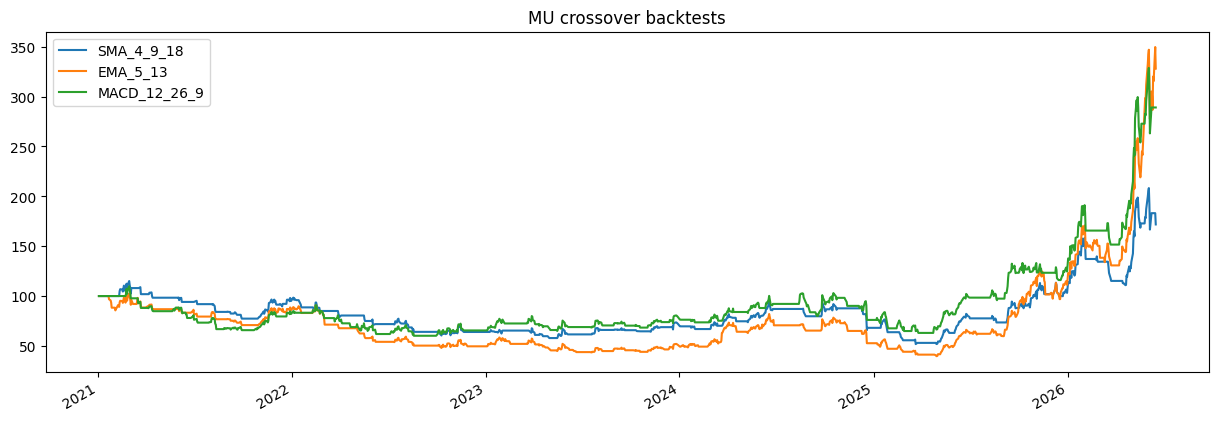

In [296]:
# ----- Backtest the crossover systems with bt -----
# Single-asset price frame (column named after the ticker, as bt expects).
price_data = df[['Close']].dropna().rename(columns={'Close': ticker})


def crossover_backtest(name, bull_series):
    # Hold (long) on bullish days, flat otherwise.
    sig = bull_series.reindex(price_data.index).fillna(False).astype(bool).to_frame(ticker)
    strat = bt.Strategy(name,
                        [bt.algos.SelectWhere(sig),
                         bt.algos.WeighEqually(),
                         bt.algos.Rebalance()])
    return bt.Backtest(strat, price_data)


res = bt.run(
    crossover_backtest('SMA_4_9_18',  sma_bull),
    crossover_backtest('EMA_5_13',    ema_bull),
    crossover_backtest('MACD_12_26_9', macd_bull),
)
res.display()
res.plot(title=f'{ticker.upper()} crossover backtests')
plt.show()

# Fundamental analysis — earnings growth & valuation

Everything above is *technical* (price/volume driven). This section adds the *fundamental* view: **is the business growing, and is the price reasonable for that growth?** Data is pulled live from Yahoo Finance via `yfinance` for the current `ticker` — it's free data, so sanity-check against the company's filings before acting on it.

- **Earnings growth** — revenue, net income and EPS trends, profit margins, and earnings surprises.
- **Valuation** — P/E (trailing & forward), PEG, Price/Sales, Price/Book, EV/EBITDA, FCF yield.
- **The bridge** — *PEG = P/E ÷ earnings-growth rate* ties the two together; ≈ 1 is a rough "fairly priced for growth", and multiples are only meaningful **relative to** the company's own history, its peers, and the market.

In [297]:
# ===== Fundamentals: fetch + valuation / growth snapshot =====
tk = yf.Ticker(ticker.upper())
finfo = tk.info
income = tk.income_stmt        # annual income statement (most-recent column first)
cashflow = tk.cashflow


def f_ratio(x):
    return f'{x:.1f}x' if isinstance(x, (int, float)) and x == x else '—'


def f_pct(x):
    return f'{x*100:.1f}%' if isinstance(x, (int, float)) and x == x else '—'


def f_usd(x):
    if not isinstance(x, (int, float)) or x != x:
        return '—'
    a = abs(x)
    for d, s in [(1e12, 'T'), (1e9, 'B'), (1e6, 'M')]:
        if a >= d:
            return f'${x/d:.2f}{s}'
    return f'${x:,.0f}'


def stmt_row(stmt, label):
    """A statement row as a chronological (old -> new) float Series indexed by year."""
    if stmt is not None and not stmt.empty and label in stmt.index:
        s = stmt.loc[label].dropna().iloc[::-1]
        s.index = [str(c.year) for c in s.index]
        return s.astype(float)
    return pd.Series(dtype=float)


def cagr(s):
    s = s[s > 0]
    if len(s) < 2:
        return None
    return (s.iloc[-1] / s.iloc[0]) ** (1 / (len(s) - 1)) - 1


price = finfo.get('currentPrice') or finfo.get('previousClose')
fcf, mcap = finfo.get('freeCashflow'), finfo.get('marketCap')
drate = finfo.get('dividendRate')
peg = finfo.get('trailingPegRatio') or finfo.get('pegRatio')

snapshot = pd.DataFrame([
    ('Valuation', 'Trailing P/E',          f_ratio(finfo.get('trailingPE'))),
    ('Valuation', 'Forward P/E',           f_ratio(finfo.get('forwardPE'))),
    ('Valuation', 'PEG (trailing)',        f_ratio(peg)),
    ('Valuation', 'Price / Sales',         f_ratio(finfo.get('priceToSalesTrailing12Months'))),
    ('Valuation', 'Price / Book',          f_ratio(finfo.get('priceToBook'))),
    ('Valuation', 'EV / EBITDA',           f_ratio(finfo.get('enterpriseToEbitda'))),
    ('Valuation', 'FCF yield',             f_pct(fcf / mcap if fcf and mcap else None)),
    ('Valuation', 'Dividend yield',        f_pct(drate / price if drate and price else None)),
    ('Growth & profitability', 'Revenue growth (YoY)',  f_pct(finfo.get('revenueGrowth'))),
    ('Growth & profitability', 'Earnings growth (YoY)', f_pct(finfo.get('earningsGrowth'))),
    ('Growth & profitability', 'Gross margin',          f_pct(finfo.get('grossMargins'))),
    ('Growth & profitability', 'Operating margin',      f_pct(finfo.get('operatingMargins'))),
    ('Growth & profitability', 'Net margin',            f_pct(finfo.get('profitMargins'))),
    ('Growth & profitability', 'Return on equity',      f_pct(finfo.get('returnOnEquity'))),
    ('Size', 'Market cap',                 f_usd(mcap)),
    ('Size', 'Revenue (TTM)',              f_usd(finfo.get('totalRevenue'))),
], columns=['Group', 'Metric', 'Value']).set_index(['Group', 'Metric'])

print(f"{finfo.get('shortName', ticker.upper())}  |  sector: {finfo.get('sector', '—')}  |  price: {f_usd(price)}")
snapshot

Micron Technology, Inc.  |  sector: Technology  |  price: $1,021


Value
Group                  Metric                        
Valuation              Trailing P/E             48.1x
                       Forward P/E               8.9x
                       PEG (trailing)            0.4x
                       Price / Sales            19.8x
                       Price / Book             15.9x
                       EV / EBITDA              31.2x
                       FCF yield                 0.3%
                       Dividend yield               —
Growth & profitability Revenue growth (YoY)    196.3%
                       Earnings growth (YoY)   756.0%
                       Gross margin             58.4%
                       Operating margin         67.6%
                       Net margin               41.5%
                       Return on equity         39.8%
Size                   Market cap              $1.15T
                       Revenue (TTM)          $58.12B

## Earnings & revenue growth

The headline question: **is the business getting bigger and more profitable?** Healthy earnings growth should be **backed by revenue (top-line) growth** — not just buybacks or one-off cost cuts. The bars show the multi-year trend; the **CAGR** summarises the compound annual rate so a single great/poor year doesn't dominate.

In [298]:
# ----- Multi-year revenue, net income & EPS -----
rev = stmt_row(income, 'Total Revenue')
ni  = stmt_row(income, 'Net Income')
eps = stmt_row(income, 'Diluted EPS')
print(f'Revenue CAGR: {f_pct(cagr(rev))}   |   Diluted EPS CAGR: {f_pct(cagr(eps))}'
      f'   (FY {", ".join(rev.index)})')

fig = make_subplots(rows=2, cols=1, shared_xaxes=True, row_heights=[0.55, 0.45],
                    vertical_spacing=0.10,
                    subplot_titles=('Revenue & Net income ($B)', 'Diluted EPS ($)'))
fig.add_trace(go.Bar(x=rev.index, y=rev / 1e9, name='Revenue', marker_color='#42a5f5'), row=1, col=1)
fig.add_trace(go.Bar(x=ni.index,  y=ni / 1e9,  name='Net income', marker_color='#26a69a'), row=1, col=1)
fig.add_trace(go.Bar(x=eps.index, y=eps, name='Diluted EPS', marker_color='#ffa726',
                     showlegend=False), row=2, col=1)
fig.update_layout(**PRO_LAYOUT, height=650, barmode='group',
                  title=f'{ticker.upper()} - revenue, earnings & EPS growth')
fig.show()

Revenue CAGR: 6.7%   |   Diluted EPS CAGR: -1.0%   (FY 2022, 2023, 2024, 2025)


## Profit margins

Margins tell you **where** the growth comes from. Rising **gross/operating margins** point to pricing power and operating leverage; flat margins with rising revenue mean growth is being "bought" with volume or spend. The gap between gross → operating → net margin shows how much of each sales dollar survives cost of goods, operating expenses, then interest and tax.

In [299]:
# ----- Profit margin trend -----
rev   = stmt_row(income, 'Total Revenue')
gross = stmt_row(income, 'Gross Profit')
oper  = stmt_row(income, 'Operating Income')
net   = stmt_row(income, 'Net Income')

fig = go.Figure()
for series, name, color in [(gross / rev * 100, 'Gross margin',     '#42a5f5'),
                            (oper / rev * 100,  'Operating margin', '#ffa726'),
                            (net / rev * 100,   'Net margin',       '#26a69a')]:
    fig.add_trace(go.Scatter(x=series.index, y=series, name=name, mode='lines+markers',
                             line=dict(width=2, color=color)))
fig.update_layout(**PRO_LAYOUT, height=450, yaxis_title='% of revenue',
                  title=f'{ticker.upper()} - profit margin trend')
fig.show()

## Earnings surprises

Each quarter, **reported EPS vs. the analyst estimate**. A consistent pattern of **beats** signals execution quality and shapes how "priced-in" expectations are — a beat can still sell off if expectations were higher than consensus, and a miss after a long beat streak is a red flag. The lower panel shows the surprise %, green for a beat and red for a miss.

In [300]:
# ----- Earnings surprises: estimate vs reported EPS -----
try:
    ed = tk.get_earnings_dates(limit=12)
    ed = ed.dropna(subset=['Reported EPS']).sort_index()
except Exception:
    ed = None

if ed is None or ed.empty:
    print('No earnings-surprise history available for', ticker.upper())
else:
    x = [d.strftime('%Y-%m-%d') for d in ed.index]
    fig = make_subplots(rows=2, cols=1, shared_xaxes=True, row_heights=[0.6, 0.4],
                        vertical_spacing=0.10, subplot_titles=('Estimate vs reported EPS', 'Surprise (%)'))
    fig.add_trace(go.Bar(x=x, y=ed['EPS Estimate'], name='Estimate', marker_color='#90a4ae'), row=1, col=1)
    fig.add_trace(go.Bar(x=x, y=ed['Reported EPS'], name='Reported', marker_color='#42a5f5'), row=1, col=1)
    colors = ['#26a69a' if v >= 0 else '#ef5350' for v in ed['Surprise(%)']]
    fig.add_trace(go.Bar(x=x, y=ed['Surprise(%)'], name='Surprise %', marker_color=colors,
                         showlegend=False), row=2, col=1)
    fig.update_layout(**PRO_LAYOUT, height=650, barmode='group',
                      title=f'{ticker.upper()} - earnings surprises (last {len(ed)} quarters)')
    fig.show()